Check CUDA version and that GPU is working in cellpose and import other libraries.

In [1]:
!nvcc --version
!nvidia-smi

import os, shutil
import numpy as np
import matplotlib.pyplot as plt
from cellpose import core, utils, io, models, metrics
from glob import glob

use_GPU = core.use_gpu()
yn = ['NO', 'YES']
print(f'>>> GPU activated? {yn[use_GPU]}')

/bin/bash: nvcc: command not found
Thu Jul 11 15:39:02 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 545.23.08              Driver Version: 545.23.08    CUDA Version: 12.3     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA RTX A6000               On  | 00000000:1A:00.0 Off |                  Off |
| 30%   33C    P8              23W / 300W |   9572MiB / 49140MiB |      0%      Default |
|                                         |                      |                  N/A |
+--------------------------------

In [2]:
import skimage.io

# read the image

DIRECTORY = "/home/MORGRIDGE/vagrawal/vidit/dataset_v2"
files = os.listdir("/home/MORGRIDGE/vagrawal/vidit/dataset_v2")
filelist = [file for file in files if not file.startswith('.')]
annot_files = [x for x in filelist if x.endswith('png')]
annot_files.sort()

ground_truth_images = []
phenotype_images = []

for i in annot_files:
    ground_truth_images.append(DIRECTORY + '/' + i.replace('phenotype_outlines.png', 'phenotype.tif'))
    phenotype_images.append(DIRECTORY + '/' + i.replace('phenotype_outlines.png', 'nuclei-clean.tif'))

print(ground_truth_images)
print(phenotype_images)


['/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-10.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-110.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-130.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-150.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-170.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-190.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-30.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-50.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-70.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/20X_c0-DAPI_A1_Tile-90.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/C2-20X_c0-DAPI-GFP_A1_Tile-17.phenotype.tif', '/home/MORGRIDGE/vagrawal/vidit/dataset_v2/C2-20X_c0-DAPI-GFP_A1_Tile-5.phenotype.tif

In [62]:
#copy images to another folder
for i in range(len(ground_truth_images)):
    shutil.copy(ground_truth_images[i], '/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test')
    shutil.copy(phenotype_images[i], '/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test')
    break

In [2]:
#@markdown ###Path to images and masks:

train_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/train" #@param {type:"string"}
test_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/test" #@param {type:"string"}
#Define where the patch file will be saved
base = "/content"

# model name and path
#@markdown ###Name of the pretrained model to start from and new model name:
from cellpose import models
initial_model = "scratch" #@param ["cyto", "cyto3", "nuclei", "tissuenet_cp3", "livecell_cp3", "yeast_PhC_cp3", "yeast_BF_cp3", "bact_phase_cp3", "bact_fluor_cp3", "deepbacs_cp3", "scratch"]
model_name = "new_model_test" #@param {type:"string"}

# other parameters for training.
#@markdown ###Training Parameters:
#@markdown Number of epochs:
n_epochs =  100#@param {type:"number"}

Channel_to_use_for_training = "Grayscale" #@param ["Grayscale", "Blue", "Green", "Red"]

# @markdown ###If you have a secondary channel that can be used for training, for instance nuclei, choose it here:

Second_training_channel= "None" #@param ["None", "Blue", "Green", "Red"]


#@markdown ###Advanced Parameters

Use_Default_Advanced_Parameters = True #@param {type:"boolean"}
#@markdown ###If not, please input:
learning_rate = 0.1 #@param {type:"number"}
weight_decay = 0.0001 #@param {type:"number"}

if (Use_Default_Advanced_Parameters):
  print("Default advanced parameters enabled")
  learning_rate = 0.1
  weight_decay = 0.0001

#here we check that no model with the same name already exist, if so delete
model_path = "/scr/vidit/dataset_nuclei_division" + 'models/'
if os.path.exists(model_path+'/'+model_name):
  print("!! WARNING: "+model_name+" already exists and will be deleted in the following cell !!")

if len(test_dir) == 0:
  test_dir = None

# Here we match the channel to number
if Channel_to_use_for_training == "Grayscale":
  chan = 0
elif Channel_to_use_for_training == "Blue":
  chan = 3
elif Channel_to_use_for_training == "Green":
  chan = 2
elif Channel_to_use_for_training == "Red":
  chan = 1


if Second_training_channel == "Blue":
  chan2 = 3
elif Second_training_channel == "Green":
  chan2 = 2
elif Second_training_channel == "Red":
  chan2 = 1
elif Second_training_channel == "None":
  chan2 = 0

if initial_model=='scratch':
  initial_model = 'None'

Default advanced parameters enabled


## Set of code to get the mask

In [7]:
import glob
import skimage
import matplotlib.pyplot as plt
import numpy as np
import scipy
#Display the .tif images in the folder
file_path = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/train/20X_c0-DAPI_A1_Tile-10.nuclei-clean.tif"

train_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/train"
test_dir = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/test"

train_label = []

for file_path in glob.glob(train_dir + '/*.png'):
  img = skimage.io.imread(file_path)
  img = img[:, :, 0]
  mask = scipy.ndimage.binary_fill_holes(img) ^ img
  # Transform annotations to labels
  labels = skimage.measure.label(mask)
  labels = skimage.morphology.dilation(labels)  # recover object edge
  #np.save(file_path.replace('nuclei-clean.tif', 'phenotype_seg.npy'), labels)
  train_label.append(labels)

train_label = np.array(train_label)
print(train_label.shape)

(1700, 296, 296)


In [ ]:
test_label = []
import glob
import scipy
for file_path in glob.glob("/home/MORGRIDGE/vagrawal/vidit/dataset_v2" + '/*nuclei-clean.tif'):
  img = skimage.io.imread(file_path, as_gray=True)
  seg = img > 0
  plt.imshow(seg, cmap='gray')
  plt.show()

  plt.savefig(file_path.replace('nuclei-clean.tif', 'nuclei_outlines.png'))

'''
  mask = scipy.ndimage.binary_fill_holes(img) ^ img
  # Transform annotations to labels
  labels = skimage.measure.label(mask)
  labels = skimage.morphology.dilation(labels)  # recover object edge
  #np.save(file_path.replace('.tif', '_seg.npy'), labels)
  test_label.append(labels)

  # Display the labels and the image
  #fig, ax = plt.subplots(1, 2, figsize=(10, 5))
  #ax[0].imshow(labels, cmap='gray')
  #ax[1].imshow(img, cmap='gray')
  #plt.show()

print(len(test_label))

'''

## Directly start to import things

In [4]:
train_label = []
test_label = []
import skimage
import glob
for file_path in glob.glob(train_dir + '/*.png'):
    img = skimage.io.imread(file_path)
    train_label.append(img)


#make it N, C, H, W
train_data = []

for file_path in glob.glob(train_dir + '/*.tif'):
    img = skimage.io.imread(file_path)
    # Make the image N, C, H, W
    #img = np.expand_dims(img, axis=0)  # Add channel dimension (C=1)
    img = img.tolist()  # Convert numpy array to a nested list
    train_data.append(img)



#make both arrays numpy
train_data = np.array(train_data)
train_label = np.array(train_label)

#Make train_label from N, H, W, C to N, C, H, W
train_label = np.moveaxis(train_label, -1, 1)
train_data = np.moveaxis(train_data, -1, 1)

print(train_data.shape)
print(train_label.shape)


(1700, 3, 296, 296)
(1700, 3, 296, 296)


In [12]:
test_label = []
import glob
for file_path in glob.glob(test_dir + '/*.png'):
    img = skimage.io.imread(file_path)
    test_label.append(img)


#make it N, C, H, W
test_data = []

for file_path in glob.glob(test_dir + '/*.tif'):
    img = skimage.io.imread(file_path)
    # Make the image N, C, H, W
    img = img.tolist()  # Convert numpy array to a nested list
    test_data.append(img)



#make both arrays numpy
test_data = np.array(test_data)
test_label = np.array(test_label)

#Make train_label from N, H, W, C to N, C, H, W
test_label = np.moveaxis(test_label, -1, 1)
test_data = np.moveaxis(test_data, -1, 1)

print(test_data.shape)
print(test_label.shape)

(100, 3, 296, 296)
(100, 3, 296, 296)


Here's what the command to train would be on the command line -- make sure if you run this locally to correct the paths for your local computer.

## Train new model

Using settings from form above, train model in notebook.

In [3]:
from cellpose import train

# start logger (to see training across epochs)
logger = io.logger_setup()

# DEFINE CELLPOSE MODEL (without size model)
model = models.CellposeModel(gpu=use_GPU, model_type=initial_model)

# set channels
channels = [0, 0]

#Train data is N, C, H, W
#Labels are N, H, W
train_dir = "/scr/vidit/dataset_sliding_division"

# get files
output = io.load_train_test_data(train_dir=train_dir, mask_filter= '_outlines')

# dimensions of train_data (18, 2960, 2960)

train_data, train_label, train_image_names, _, _, _ = output

#print(len(train_data[0][0]))
#print(len(train_label))

#296x296 size, 1700 images

#print(type(train_data))

save_path = "/scr/vidit/sliding_models"
new_model_path = train.train_seg(model.net, train_data=train_data,
                              train_labels=train_label,
                              #test_data=test_data,
                              #test_labels=test_label,
                              channels=channels,
                              save_path=save_path,
                              n_epochs=100,
                              learning_rate=0.1,
                              weight_decay=weight_decay,
                              SGD=True,
                              min_train_masks = 1,
                              nimg_per_epoch=8,
                              normalize=True,
                              model_name=model_name)



# diameter of labels in training images
diam_labels = model.net.diam_labels.item()

2024-07-11 15:39:20,306 [INFO] WRITING LOG OUTPUT TO /home/MORGRIDGE/vagrawal/.cellpose/run.log
2024-07-11 15:39:20,307 [INFO] 
cellpose version: 	3.0.11.dev1+g84344b0 
platform:       	linux 
python version: 	3.11.0 
torch version:  	2.3.0
2024-07-11 15:39:20,308 [WARNING] model_type does not exist, using default model
2024-07-11 15:39:20,309 [INFO] ** TORCH CUDA version installed and working. **
2024-07-11 15:39:20,309 [INFO] >>>> using GPU
2024-07-11 15:39:20,401 [INFO] >>>> no model weights loaded
2024-07-11 15:39:21,300 [INFO] not all flows are present, running flow generation for all images
2024-07-11 15:40:06,609 [INFO] 10588 / 10588 images in /scr/vidit/dataset_sliding_division folder have labels
2024-07-11 15:40:06,617 [INFO] computing flows for labels


100%|██████████| 10588/10588 [05:54<00:00, 29.84it/s]

2024-07-11 15:46:04,068 [INFO] >>> computing diameters



100%|██████████| 10588/10588 [00:03<00:00, 2658.58it/s]

2024-07-11 15:46:08,052 [INFO] >>> using channels [0, 0]
2024-07-11 15:46:08,053 [INFO] >>> normalizing {'lowhigh': None, 'percentile': None, 'normalize': True, 'norm3D': False, 'sharpen_radius': 0, 'smooth_radius': 0, 'tile_norm_blocksize': 0, 'tile_norm_smooth3D': 1, 'invert': False}


2024-07-11 15:46:56,294 [INFO] >>> n_epochs=100, n_train=10588, n_test=None
2024-07-11 15:46:56,295 [INFO] >>> SGD, learning_rate=0.10000, weight_decay=0.00010, momentum=0.900
2024-07-11 15:46:57,102 [INFO] >>> saving model to /scr/vidit/sliding_models/models/new_model_test
2024-07-11 15:46:57,989 [INFO] 0, train_loss=2.0367, test_loss=0.0000, LR=0.0000, time 0.89s
2024-07-11 15:46:58,503 [INFO] 5, train_loss=1.5197, test_loss=0.0000, LR=0.0556, time 1.40s
2024-07-11 15:46:59,015 [INFO] 10, train_loss=0.7985, test_loss=0.0000, LR=0.1000, time 1.91s
2024-07-11 15:47:00,032 [INFO] 20, train_loss=0.5143, test_loss=0.0000, LR=0.1000, time 2.93s
2024-07-11 15:47:01,002 [INFO] 30, train_loss=0.4493, test_loss=0.0000, LR=0.1000, time 3.90s
2024-07-11 15:47:01,937 [INFO] 40, train_loss=0.3322, test_loss=0.0000, LR=0.1000, time 4.84s
2024-07-11 15:47:02,881 [INFO] 50, train_loss=0.3868, test_loss=0.0000, LR=0.1000, time 5.78s
2024-07-11 15:47:03,853 [INFO] 60, train_loss=0.3139, test_loss=0.000

## Evaluate on test data (optional)

If you have test data, check performance

In [15]:
# run model on test images
masks = model.eval(test_data,
                   channels=[0, 0],
                   diameter=diam_labels)[0]



2024-06-24 17:26:22,921 [INFO] multi-stack tiff read in as having 100 planes 3 channels
2024-06-24 17:26:36,596 [INFO] 100%|##########| 100/100 [00:13<00:00,  7.38it/s]
2024-06-24 17:26:36,597 [INFO] network run in 13.56s
2024-06-24 17:26:36,597 [INFO] 0%|          | 0/100 [00:00<?, ?it/s]
2024-06-24 17:26:36,598 [INFO] No cell pixels found.
2024-06-24 17:26:36,599 [INFO] No cell pixels found.
2024-06-24 17:26:36,599 [INFO] No cell pixels found.
2024-06-24 17:26:36,600 [INFO] No cell pixels found.
2024-06-24 17:26:36,600 [INFO] No cell pixels found.
2024-06-24 17:26:36,601 [INFO] No cell pixels found.
2024-06-24 17:26:36,601 [INFO] No cell pixels found.
2024-06-24 17:26:36,602 [INFO] No cell pixels found.
2024-06-24 17:26:36,602 [INFO] No cell pixels found.
2024-06-24 17:26:36,603 [INFO] No cell pixels found.
2024-06-24 17:26:36,603 [INFO] No cell pixels found.
2024-06-24 17:26:36,604 [INFO] No cell pixels found.
2024-06-24 17:26:36,604 [INFO] No cell pixels found.
2024-06-24 17:26:36,

In [17]:
masks.shape

(100, 296, 296)

In [ ]:
true_mask = np.load("/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/test/20X_c0-DAPI_A1_Tile-10.phenotype.npy", allow_pickle=True)
plt.imshow(true_mask, cmap='gray')

print(np.unique(true_mask))
plt.show()

In [17]:
# get files (during training, test_data is transformed so we will load it again)

import skimage
test_label = []
import glob
for file_path in glob.glob(test_dir + '/*phenotype*_outlines.png'):
    img = skimage.io.imread(file_path, as_gray=True)
    test_label.append(img)


#make it N, C, H, W
test_data = []

for file_path in glob.glob(test_dir + '/*phenotype*.tif'):
    img = skimage.io.imread(file_path, as_gray=True)
    # Make the image N, C, H, W
    img = np.expand_dims(img, axis=0)  # Add channel dimension (C=1)
    img = img.tolist()  # Convert numpy array to a nested list
    test_data.append(img)

print(len(test_data))
print(len(test_label))


#make both arrays numpy
test_data = np.array(test_data)
test_label = np.array(test_label)

print(test_data.shape)
print(test_label.shape)




#output = io.load_train_test_data(test_dir, mask_filter='_seg.npy')
#test_data, _ = output[:2]

# run model on test images
masks = model.eval(test_data,
                   channels=[1, 0],
                   diameter=diam_labels)[0]

print(type(masks))



100
100
(100, 1, 296, 296)
(100, 296, 296)


NameError: name 'model' is not defined

In [80]:
# Command line for evaluation
!cellpose --dir . --pretrained_model ../models/new_model_scratch --chan 0 --chan2 0 --save_png --verbose --use_gpu

2024-06-21 01:28:59,925 [INFO] WRITING LOG OUTPUT TO /home/MORGRIDGE/vagrawal/.cellpose/run.log
2024-06-21 01:28:59,925 [INFO] 
cellpose version: 	3.0.11.dev1+g84344b0 
platform:       	linux 
python version: 	3.11.0 
torch version:  	2.3.0
2024-06-21 01:28:59,925 [INFO] >>>> using CPU
2024-06-21 01:28:59,926 [WARNING] pretrained model has incorrect path, using cyto3
Traceback (most recent call last):
  File "/home/MORGRIDGE/vagrawal/vidit/anaconda3/bin/cellpose", line 8, in <module>
    sys.exit(main())
             ^^^^^^
  File "/scr/vidit/anaconda3/lib/python3.11/site-packages/cellpose/__main__.py", line 134, in main
    image_names = io.get_image_files(
                  ^^^^^^^^^^^^^^^^^^^
  File "/scr/vidit/anaconda3/lib/python3.11/site-packages/cellpose/io.py", line 313, in get_image_files
    raise ValueError(
ValueError: ERROR: no images in --dir folder with extensions .png, .jpg, .jpeg, .tif, .tiff


In [33]:
file_path = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/test/C2-20X_c0-DAPI-GFP_B3_Tile-10.phenotype_52_seg.npy"
img = np.load(file_path, allow_pickle=True)
print("Data type of the numpy array:", img.dtype)
print("Type of the first element:", type(img.flat[0]))
# Check the first dictionary to understand the structure
first_element = img.flat[0]
print("Keys in the dictionary:", first_element.keys())
for key, value in first_element.items():
    print(f"Key: {key}, Type of value: {type(value)}")
img.flat[0]['masks'].shape



Data type of the numpy array: object
Type of the first element: <class 'dict'>
Keys in the dictionary: dict_keys(['outlines', 'masks', 'chan_choose', 'ismanual', 'filename', 'flows', 'diameter'])
Key: outlines, Type of value: <class 'numpy.ndarray'>
Key: masks, Type of value: <class 'numpy.ndarray'>
Key: chan_choose, Type of value: <class 'list'>
Key: ismanual, Type of value: <class 'numpy.ndarray'>
Key: filename, Type of value: <class 'str'>
Key: flows, Type of value: <class 'list'>
Key: diameter, Type of value: <class 'float'>


(296, 296)

In [2]:
import sys
sys.path.append('../')  # Add the outer directory to the system path
import glob
import skimage
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

results = []

test_dir = "/scr/vidit/dataset_nuclei"

from microdet.evaluation import compare_two_labels
for file_path in glob.glob(test_dir + '/*phenotype_*_outlines.png'):
    gt_label = skimage.io.imread(file_path, as_gray=True)
    num = file_path.split('_')[-2]
    for seg_file_path in glob.glob(test_dir + '/*phenotype_'+num+'_seg.npy'):
        seg_import = np.load(seg_file_path, allow_pickle=True)
        results.append(compare_two_labels(seg_import.flat[0]['masks'], gt_label, False))
        plt.imshow(gt_label, cmap='gray')
        plt.show()
        plt.imshow(seg_import.flat[0]['masks'], cmap='gray')
        plt.show()



569
553


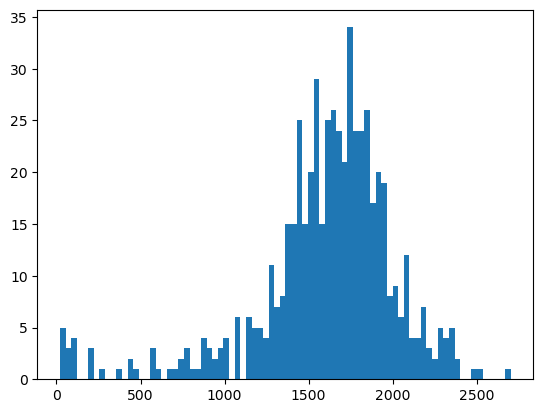

17
[  0   1   3  74 108 126 141 159 189 269 352 353 355 358 362 397 406]


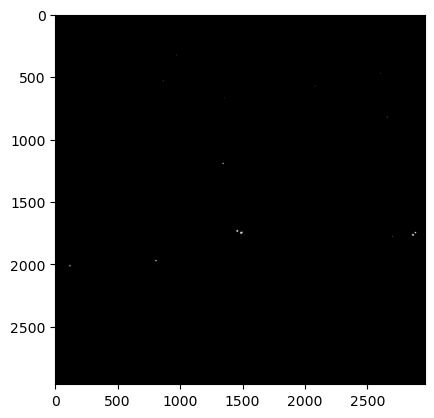

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72 73 74 75 76 77 78 79 80 81 82 83 84 85]


In [7]:
import skimage
import matplotlib.pyplot as plt
import numpy as np
import scipy
nuclei_mask_path = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/nuclei-train/20X_c0-DAPI_A1_Tile-10.phenotype_cp_masks.png"
micronuclei_mask_path = "/home/MORGRIDGE/vagrawal/vidit/sliding_models/20X_c0-DAPI_A1_Tile-10.phenotype_cp_masks.png"
micronuclei_gt = "/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/20X_c0-DAPI_A1_Tile-10.phenotype_outlines.png"

micronuclei_gt = skimage.io.imread(micronuclei_gt)
micronuclei_gt = micronuclei_gt[:,:,0] > 0 # Use only the red channel
micronuclei_gt = scipy.ndimage.binary_fill_holes(micronuclei_gt) ^ micronuclei_gt
#Merge seg and outlines_img together, overlay the outlines_img on seg
micronuclei_gt = skimage.measure.label(micronuclei_gt)
# Not doing object edge detection as the objects start touching then
micronuclei_gt = skimage.morphology.dilation(micronuclei_gt)  # recover object edge


micronuclei_img = skimage.io.imread(micronuclei_mask_path, as_gray=True)
nuclei_img = skimage.io.imread(nuclei_mask_path, as_gray=True)
image_stats = skimage.measure.regionprops(micronuclei_img)



full_area = []
area_label_number = []
print(len(image_stats))

for i in range(len(image_stats)):
    if(image_stats[i].area > 300.0):
        area_label_number.append(image_stats[i].label)
    full_area.append(image_stats[i].area)


print(len(np.unique(area_label_number)))

plt.hist(full_area, bins=80)
plt.show()

for i in area_label_number:
    micronuclei_img[micronuclei_img == i] = 0
print(len(np.unique(micronuclei_img)))
print(np.unique(micronuclei_img))
plt.imshow(micronuclei_img, cmap='gray')
plt.show()



# The numbering is not ascending order, can we make it so that it is ascending order again

# Get the unique values in the image
unique_values = np.unique(micronuclei_img)
# Create a dictionary to map the old values to the new values
value_map = {value: i for i, value in enumerate(unique_values)}
# Apply the mapping to the image
micronuclei_img = np.vectorize(value_map.get)(micronuclei_img)
# Check the unique values again
print(np.unique(micronuclei_img))
print(np.unique(micronuclei_gt))



In [8]:
#Evaluation
import sys
sys.path.append('../')
from microdet.evaluation import compare_two_labels, measures_at
nb_overdetection, nb_underdetection, mean_IoU, IoUs = compare_two_labels(micronuclei_gt, micronuclei_img, True, False)
f1, prec, rec, TP, FP, FN = measures_at(0.1, IoUs)
print(f"F1-score: {f1:.2f}")
print(f"Precision: {prec:.2f}")
print(f"Recall: {rec:.2f}")
print(f"True positives: {TP}")
print(f"False positives: {FP}")
print(f"False negatives: {FN}")

F1-score: 0.28
Precision: 0.16
Recall: 0.88
True positives: 14
False positives: 71
False negatives: 2


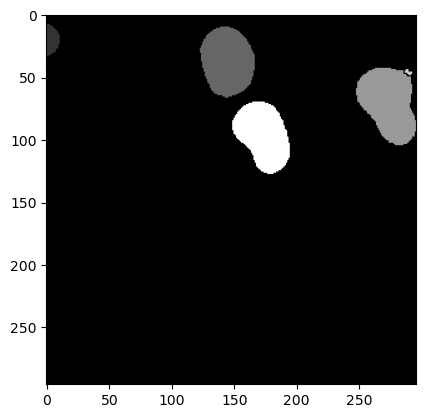

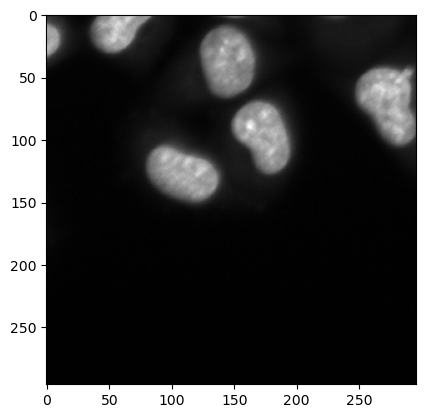

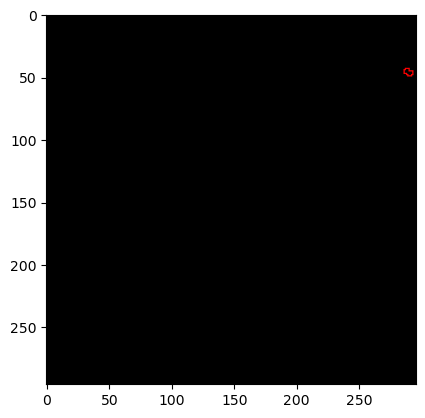

In [12]:
import skimage
import matplotlib.pyplot as plt
img = skimage.io.imread("/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/test/20X_c0-DAPI_A1_Tile-10.81_phenotype_outlines_cp_masks.png", as_gray=True)
outline = skimage.io.imread("/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/test/20X_c0-DAPI_A1_Tile-10.phenotype_81.tif", as_gray=True)
gt = skimage.io.imread("/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/20X_c0-DAPI_A1_Tile-10.phenotype_outlines_81.png")

plt.imshow(img, cmap='gray')
plt.show()
plt.imshow(outline, cmap='gray')
plt.show()
plt.imshow(gt, cmap='gray')
plt.show()

#img_prob = skimage.io.imread("/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei_division/test/")

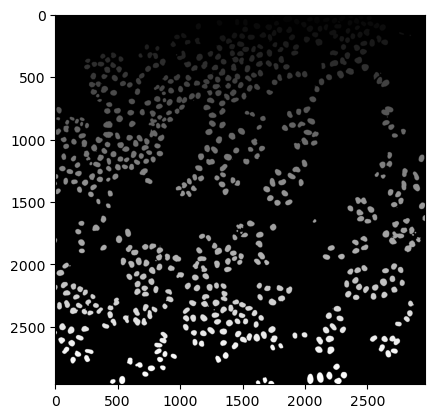

In [4]:
import skimage
import matplotlib.pyplot as plt
# !cellpose --dir . --pretrained_model ../dataset_nuclei_division/models/new_model_scratch --chan 0 --chan2 0 --save_png --verbose --use_gpu
img = skimage.io.imread("/home/MORGRIDGE/vagrawal/vidit/dataset_nuclei/20X_c0-DAPI_A1_Tile-10.phenotype_cp_masks.png")
plt.imshow(img, cmap='gray')
plt.show()